In [1]:
pip install rasterio geopandas shapely segmentation-models-pytorch albumentations

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install patchify rasterio shapely segmentation-models-pytorch albumentations

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


In [5]:
import os, json, rasterio, glob
import numpy as np
from rasterio.windows import Window
from rasterio import features
from shapely.geometry import Polygon

# Corrected paths based on your localhost structure
RAW_DIR = '../raw_data'   
OUT_DIR = '../train_data'   
TILE_SIZE = 512
OVERLAP = 128            

def process_step_one_final():
    os.makedirs(os.path.join(OUT_DIR, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT_DIR, "masks"), exist_ok=True)
    
    stride = TILE_SIZE - OVERLAP 
    # Search for anything ending in .tif inside the raw_data folder
    tif_files = glob.glob(os.path.join(RAW_DIR, "*.tif"))
    
    print(f"🔍 Searching in: {os.path.abspath(RAW_DIR)}")
    print(f"🔍 Found {len(tif_files)} TIFF images.")

    for tif_path in tif_files:
        filename = os.path.basename(tif_path)
        # Extract the scene name (e.g., MussettBayouFire-01)
        file_prefix = filename.split('_tif')[0]
        
        base_json = os.path.join(RAW_DIR, f"{file_prefix}_json.json")
        align_json = os.path.join(RAW_DIR, f"{file_prefix}_json_aligned.json")
        
        if not os.path.exists(base_json) or not os.path.exists(align_json):
            print(f"⚠️ Missing JSON for {file_prefix}, checking alternative names...")
            # Fallback for different naming conventions
            file_prefix = filename.split('_')[0]
            base_json = os.path.join(RAW_DIR, f"{file_prefix}_json.json")
            align_json = os.path.join(RAW_DIR, f"{file_prefix}_json_aligned.json")
            if not os.path.exists(base_json): continue

        print(f"🏗️ Processing Scene: {file_prefix}")

        # --- A. Alignment Logic ---
        with open(align_json) as f:
            align_data = json.load(f)
        s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
        s_y = np.mean([p[1][1] - p[0][1] for p in align_data])
        
        with rasterio.open(tif_path) as src:
            # --- B. Create Mask from Aligned Polygons ---
            with open(base_json) as f:
                polys = []
                for entry in json.load(f):
                    if 'pixels' in entry:
                        c = [(p['x'] + s_x, p['y'] + s_y) for p in entry['pixels']]
                        world_c = [src.transform * (px, py) for px, py in c]
                        polys.append(Polygon(world_c))

            # --- C. Overlapping Tiling ---
            for y in range(0, src.height - TILE_SIZE, stride):
                for x in range(0, src.width - TILE_SIZE, stride):
                    window = Window(x, y, TILE_SIZE, TILE_SIZE)
                    mask = features.rasterize(
                        polys, 
                        out_shape=(TILE_SIZE, TILE_SIZE), 
                        transform=src.window_transform(window), 
                        fill=0, default_value=1, dtype=np.uint8
                    )
                    
                    if np.sum(mask) > 50: # Only save if a building is present
                        tile_id = f"{file_prefix}_y{y}_x{x}.npy"
                        img_patch = src.read([1, 2, 3], window=window)
                        np.save(os.path.join(OUT_DIR, "images", tile_id), img_patch.transpose(1, 2, 0))
                        np.save(os.path.join(OUT_DIR, "masks", tile_id), mask)

    total_images = len(os.listdir(os.path.join(OUT_DIR, "images")))
    print(f"✅ Step 1 Complete! Generated {total_images} tiles.")

process_step_one_final()

🔍 Searching in: /Users/shashank/Building_Damage_Project/raw_data
🔍 Found 10 TIFF images.
🏗️ Processing Scene: MussettBayouFire-03
🏗️ Processing Scene: eruption-03
🏗️ Processing Scene: laura-01
🏗️ Processing Scene: eruption-02
🏗️ Processing Scene: MussettBayouFire-02
🏗️ Processing Scene: MussettBayouFire-01
🏗️ Processing Scene: laura-02
🏗️ Processing Scene: eruption-01
🏗️ Processing Scene: MussettBayouFire-04
🏗️ Processing Scene: MussettBayouFire-05
✅ Step 1 Complete! Generated 4515 tiles.


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

class BuildingDataset(Dataset):
    def __init__(self, data_dir='../train_data'):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        # List all .npy files generated in Step 1
        self.filenames = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        # Load the image and mask arrays
        img = np.load(os.path.join(self.img_dir, self.filenames[idx]))
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx]))
        
        # 1. Normalize Image: Convert 0-255 to 0.0-1.0
        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32)
        
        # 2. Reshape for PyTorch: (H, W, C) -> (C, H, W)
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        # Add a channel dimension to the mask: (H, W) -> (1, H, W)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)
        
        return img_tensor, mask_tensor

# Initialize the DataLoader
dataset = BuildingDataset()
# Adjust batch_size based on your GPU memory (8-16 is usually safe)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

print(f"✅ Step 2 Complete: Dataset loaded with {len(dataset)} training tiles.")

✅ Step 2 Complete: Dataset loaded with 4514 training tiles.


In [5]:
# 1. Uninstall the conflicting packages
!pip uninstall -y numpy matplotlib torchvision torchaudio torch

# 2. Reinstall compatible versions
!pip install numpy==1.24.3 matplotlib==3.7.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install segmentation-models-pytorch

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: matplotlib 3.10.8
Uninstalling matplotlib-3.10.8:
  Successfully uninstalled matplotlib-3.10.8
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached numpy-1.24.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.6 kB)
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement matplotlib==3.7.1 (from versions: none)
ERROR: No matching distribution

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import os
import numpy as np
import time

# --- RE-DEFINING DATASET (Step 2) ---
class BuildingDataset(Dataset):
    def __init__(self, data_dir='../train_data'):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        self.filenames = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img = np.load(os.path.join(self.img_dir, self.filenames[idx])).astype(np.float32) / 255.0
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx])).astype(np.float32)
        
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)
        return img_tensor, mask_tensor

# Initialize the objects
dataset = BuildingDataset()
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

# --- RE-DEFINING MODEL (Step 3) ---
# U-Net uses skip connections to preserve the building edges you verified.
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                      
    activation='sigmoid'            
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dice Loss is the grader; it forces the model to overlap with your building masks.
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print(f"✅ Success: Dataset '{len(dataset)} tiles' and Model are ready on {device}.")

✅ Success: Dataset '1167 tiles' and Model are ready on cpu.


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import time

# 1. FIXED SPLIT: Ensuring the 20% test set is 100% consistent
# Using manual_seed(42) ensures we pick the same 233 tiles every time you run this.
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_subset, test_subset = random_split(dataset, [train_size, test_size], 
                                         generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=8, shuffle=False)

# 2. THE OPTIMIZED MODEL: U-Net with ResNet-34
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(device)

# 3. OPTIMIZED LOSS: Tversky Loss
# Penalizing missing building pixels (False Negatives) more than extra pixels.
# This forces the model to draw the WHOLE building footprint accurately.
criterion = smp.losses.TverskyLoss(mode='binary', alpha=0.7, beta=0.3)

# 4. SCHEDULER: Adam Optimizer + Learning Rate Decay
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
# If Test Loss doesn't improve for 3 epochs, cut the learning rate by 10x.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print(f"🚀 Optimized setup ready on {device}. Training on {len(train_subset)} tiles, Testing on {len(test_subset)}.")

🚀 Optimized setup ready on cpu. Training on 933 tiles, Testing on 234.


In [7]:
!pip uninstall -y numpy matplotlib torchvision torch
!pip install numpy==1.26.4 matplotlib==3.8.2 torch torchvision segmentation-models-pytorch

Found existing installation: numpy 2.4.2
Uninstalling numpy-2.4.2:
  Successfully uninstalled numpy-2.4.2
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached matplotlib-3.8.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.8 kB)
  Using cached torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.4 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached matplotlib-3.8.2-cp311-cp311-macosx_11_0_arm64.whl (7.5 MB)
Using cached torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl (79.4 MB)
Using cached torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl (1.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
import torch

# 1. Check if CUDA (NVIDIA GPU support) is available
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

# 2. Get specific GPU details if available
if cuda_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
else:
    print("⚠️ PyTorch is currently restricted to the CPU.")
    print("Check if you have an NVIDIA GPU and the correct drivers installed.")

CUDA Available: False
⚠️ PyTorch is currently restricted to the CPU.
Check if you have an NVIDIA GPU and the correct drivers installed.


In [9]:
import torch
from torch.utils.data import DataLoader, random_split
import time

# 1. Dataset Splitting (80% Train, 20% Test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_subset, test_subset = random_split(dataset, [train_size, test_size])

# 2. Create Loaders
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=8, shuffle=False)

print(f"🏠 Training on: {len(train_subset)} tiles")
print(f"🔍 Testing on: {len(test_subset)} tiles")

# 3. Training Loop with Periodic Testing
num_epochs = 30 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    start_time = time.time()
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device).float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # --- TESTING PHASE (Evaluation) ---
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device).float()
            outputs = model(images)
            loss = criterion(outputs, masks)
            test_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Time: {time.time()-start_time:.2f}s")

# 4. Save Final Weights
torch.save(model.state_dict(), "mussett_bayou_unet_v2.pth")
print("✅ Split-training complete! Model saved as 'mussett_bayou_unet_v2.pth'")

🏠 Training on: 933 tiles
🔍 Testing on: 234 tiles
Epoch [1/30] | Train Loss: 0.5168 | Test Loss: 0.5207 | Time: 571.30s
Epoch [2/30] | Train Loss: 0.5000 | Test Loss: 0.5124 | Time: 575.27s
Epoch [3/30] | Train Loss: 0.4912 | Test Loss: 0.5097 | Time: 589.79s
Epoch [4/30] | Train Loss: 0.4865 | Test Loss: 0.5056 | Time: 589.20s
Epoch [5/30] | Train Loss: 0.4834 | Test Loss: 0.5072 | Time: 583.88s
Epoch [6/30] | Train Loss: 0.4827 | Test Loss: 0.5064 | Time: 579.34s
Epoch [7/30] | Train Loss: 0.4780 | Test Loss: 0.5013 | Time: 590.87s
Epoch [8/30] | Train Loss: 0.4752 | Test Loss: 0.5129 | Time: 593.20s
Epoch [9/30] | Train Loss: 0.4747 | Test Loss: 0.4998 | Time: 620.41s
Epoch [10/30] | Train Loss: 0.4727 | Test Loss: 0.5024 | Time: 615.56s
Epoch [11/30] | Train Loss: 0.4698 | Test Loss: 0.4980 | Time: 609.80s
Epoch [12/30] | Train Loss: 0.4719 | Test Loss: 0.4999 | Time: 595.63s
Epoch [13/30] | Train Loss: 0.4704 | Test Loss: 0.4970 | Time: 594.54s
Epoch [14/30] | Train Loss: 0.4700 | 

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import os
from tqdm import tqdm

# ----------------------------
# DATASET (same as training)
# ----------------------------
class BuildingDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir='../train_data'):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        self.filenames = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img = np.load(os.path.join(self.img_dir, self.filenames[idx])).astype(np.float32) / 255.0
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx])).astype(np.float32)

        img = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask

# ----------------------------
# DEVICE
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# LOAD DATA
# (same split as training – IMPORTANT)
# ----------------------------
dataset = BuildingDataset()

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_subset, test_subset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)   # ← keep SAME seed
)

test_loader = DataLoader(test_subset, batch_size=8, shuffle=False)

# ----------------------------
# LOAD MODEL
# ----------------------------
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(device)

model.load_state_dict(torch.load("mussett_bayou_unet_v2.pth", map_location=device))
model.eval()

# ----------------------------
# METRIC FUNCTION
# ----------------------------
def evaluate(model, loader, threshold=0.5):
    tp = fp = fn = tn = 0.0

    with torch.no_grad():
        for imgs, masks in tqdm(loader):
            imgs = imgs.to(device)
            masks = masks.to(device)

            probs = model(imgs)
            preds = (probs > threshold).float()

            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()
            tn += ((1 - preds) * (1 - masks)).sum().item()

    eps = 1e-7

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = (2 * precision * recall) / (precision + recall + eps)
    specificity = tn / (tn + fp + eps)
    balanced_acc = 0.5 * (recall + specificity)
    overall_acc = (tp + tn) / (tp + tn + fp + fn + eps)

    return iou, dice, precision, recall, f1, specificity, balanced_acc, overall_acc

# ----------------------------
# RUN EVALUATION
# ----------------------------
iou, dice, precision, recall, f1, specificity, bal_acc, acc = evaluate(model, test_loader)

print("\n--- 🌍 GLOBAL DISASTER FOUNDATION RESULTS ---")
print(f"IoU              : {iou:.4f}")
print(f"Dice             : {dice:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall (Target)  : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"Balanced Acc.    : {bal_acc:.4f}")
print(f"Overall Accuracy : {acc:.4f}")

  8%|███████▊                                                                                     | 141/1691 [03:29<38:27,  1.49s/it]


KeyboardInterrupt: 

In [2]:
import torch
import numpy as np
from tqdm import tqdm

def evaluate_all_metrics(loader, model, threshold=0.5):
    tp = fp = fn = tn = 0.0

    print(f"🧐 Evaluating on {len(loader)} unseen tiles...")

    with torch.no_grad():
        for images, masks in tqdm(loader):
            images = images.to(device)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)
            masks = masks.to(device).float()

            outputs = model(images)
            preds = (outputs > threshold).float()

            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()
            tn += ((1 - preds) * (1 - masks)).sum().item()

    eps = 1e-7
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = (2 * precision * recall) / (precision + recall + eps)
    specificity = tn / (tn + fp + eps)
    balanced_acc = 0.5 * (recall + specificity)
    overall_acc = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall (Target)": recall,
        "F1-score": f1,
        "Specificity": specificity,
        "Balanced Acc.": balanced_acc,
        "Overall Accuracy": overall_acc
    }

# Run
metrics = evaluate_all_metrics(test_loader, model, threshold=0.5)

print(f"\n--- 🌍 GLOBAL DISASTER FOUNDATION RESULTS ---")
print(f"IoU              : {metrics['IoU']:.4f}")
print(f"Dice             : {metrics['Dice']:.4f}")
print(f"Precision        : {metrics['Precision']:.4f}")
print(f"Recall (Target)  : {metrics['Recall (Target)']:.4f}")
print(f"F1-score         : {metrics['F1-score']:.4f}")
print(f"Specificity      : {metrics['Specificity']:.4f}")
print(f"Balanced Acc.    : {metrics['Balanced Acc.']:.4f}")
print(f"Overall Accuracy : {metrics['Overall Accuracy']:.4f}")

🧐 Evaluating on 1691 unseen tiles...


100%|████████████████████████████████████████████████████████████████████████████████████████████| 1691/1691 [43:29<00:00,  1.54s/it]


--- 🌍 GLOBAL DISASTER FOUNDATION RESULTS ---
IoU              : 0.4580
Dice             : 0.6283
Precision        : 0.5820
Recall (Target)  : 0.6825
F1-score         : 0.6283
Specificity      : 0.7768
Balanced Acc.    : 0.7296
Overall Accuracy : 0.7473


In [4]:
import torch
import numpy as np
import cv2
import os
import random
import segmentation_models_pytorch as smp

# 1. Load the Model precisely how it was trained
device = torch.device("cpu") # Using CPU to match your training session
model = smp.Unet(encoder_name="resnet34", classes=1, activation='sigmoid')
model.load_state_dict(torch.load("mussett_bayou_unet.pth", map_location=device))
model.eval()

def save_visual_results(data_dir='../train_data', out_dir='../results'):
    os.makedirs(out_dir, exist_ok=True)
    img_dir = os.path.join(data_dir, "images")
    mask_dir = os.path.join(data_dir, "masks")
    
    # Pick 5 random tiles to inspect
    all_files = [f for f in os.listdir(img_dir) if f.endswith('.npy')]
    samples = random.sample(all_files, min(5, len(all_files)))
    
    print(f"🖼️ Saving {len(samples)} visual comparisons to {out_dir}...")

    for filename in samples:
        # Load data
        img_np = np.load(os.path.join(img_dir, filename))
        mask_gt = np.load(os.path.join(mask_dir, filename))
        
        # Inference
        input_tensor = torch.from_numpy(img_np.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0)
        with torch.no_grad():
            pred = model(input_tensor)
            pred_mask = (pred.squeeze().numpy() > 0.5).astype(np.uint8) # Binary threshold
        
        # Create Visual Overlay
        # img_bgr is the base drone image
        img_bgr = cv2.cvtColor(img_np.astype(np.uint8), cv2.COLOR_RGB2BGR)
        
        # Blue overlay for Predicted Buildings
        pred_overlay = img_bgr.copy()
        pred_overlay[pred_mask == 1] = [255, 0, 0] 
        
        # Combine: 70% original, 30% blue prediction
        result_view = cv2.addWeighted(img_bgr, 0.7, pred_overlay, 0.3, 0)
        
        # Save to disk
        cv2.imwrite(os.path.join(out_dir, f"pred_{filename.replace('.npy', '.jpg')}"), result_view)

    print("✅ Inference complete. Open the '../results' folder to see your model in action!")

save_visual_results()

🖼️ Saving 5 visual comparisons to ../results...
✅ Inference complete. Open the '../results' folder to see your model in action!


In [2]:
import torch
from torch.utils.data import DataLoader, random_split
import os
import numpy as np

# 1. Re-define the Dataset class (so the notebook knows how to read your .npy files)
class BuildingDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir='../train_data'):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        self.filenames = [f for f in os.listdir(self.img_dir) if f.endswith('.npy')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img = np.load(os.path.join(self.img_dir, self.filenames[idx])).astype(np.float32) / 255.0
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx])).astype(np.float32)
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)
        return img_tensor, mask_tensor

# 2. Re-create the split
# Use a fixed 'generator' seed to ensure the test set is the SAME one as yesterday
dataset = BuildingDataset()
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_subset, test_subset = random_split(dataset, [train_size, test_size], 
                                         generator=torch.Generator().manual_seed(42))

print(f"✅ 'test_subset' successfully re-defined with {len(test_subset)} tiles.")

✅ 'test_subset' successfully re-defined with 234 tiles.


In [3]:
import torch
import numpy as np
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader

# 1. Load the "V2" Model (Split-Trained Version)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    in_channels=3,
    classes=1,
    activation='sigmoid'
)

# Load the specific weights from your latest run
model.load_state_dict(torch.load("mussett_bayou_unet_v2.pth", map_location=device))
model.to(device)
model.eval()

# 2. Use the TEST LOADER (The 20% unseen data)
# Note: Ensure 'test_subset' is the variable from your previous split cell
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

def evaluate_performance(loader, model):
    ious = []
    f1_scores = []
    
    print(f"🧐 Evaluating on {len(loader)} unseen Mussett Bayou tiles...")
    
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device).float()
            
            # Model prediction
            outputs = model(images)
            preds = (outputs > 0.5).float() # Binary threshold
            
            # Flatten to calculate pixel-wise overlap
            preds_flat = preds.view(-1)
            masks_flat = masks.view(-1)
            
            intersection = (preds_flat * masks_flat).sum()
            union = (preds_flat + masks_flat).sum() - intersection
            
            # IoU calculation
            iou = (intersection + 1e-6) / (union + 1e-6)
            ious.append(iou.item())
            
            # F1 / Dice calculation
            f1 = (2 * intersection + 1e-6) / (preds_flat.sum() + masks_flat.sum() + 1e-6)
            f1_scores.append(f1.item())
            
    return np.mean(ious), np.mean(f1_scores)

# Execute
mIoU, mF1 = evaluate_performance(test_loader, model)

print(f"\n--- 🏁 FINAL PROJECT METRICS ---")
print(f"Unseen Test IoU: {mIoU:.4f}")
print(f"Unseen Test F1-Score: {mF1:.4f}")
print(f"-------------------------------")

🧐 Evaluating on 234 unseen Mussett Bayou tiles...

--- 🏁 FINAL PROJECT METRICS ---
Unseen Test IoU: 0.8530
Unseen Test F1-Score: 0.8978
-------------------------------


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import numpy as np
import os
import time

# 1. FINAL DATASET SPLIT (80% Train, 20% Test)
# We use a fixed seed (42) so the 'unseen' test set is consistent every time.
dataset = BuildingDataset() # Uses the class you defined in Step 2
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_subset, test_subset = random_split(
    dataset, [train_size, test_size], 
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

# 2. MODEL INITIALIZATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",        # Strong, efficient backbone
    encoder_weights="imagenet",     # Transfer learning for better texture recognition
    in_channels=3,                  
    classes=1,                      
    activation='sigmoid'            
).to(device)

# 3. OPTIMIZED LOSS & OPTIMIZER
# Tversky Loss is superior to Dice for localization as it penalizes missing buildings.
criterion = smp.losses.TverskyLoss(mode='binary', alpha=0.7, beta=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Scheduler reduces LR when improvement stalls, helping fine-tune roof edges.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

# 4. TRAINING LOOP WITH CHECKPOINTING
num_epochs = 30
best_test_loss = float('inf')

print(f"🚀 Training started on {device}...")
print(f"🏠 Train: {len(train_subset)} tiles | 🔍 Test: {len(test_subset)} tiles")

for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0
    start_time = time.time()
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device).float()
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # --- EVALUATION (TESTING) ---
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device).float()
            outputs = model(images)
            loss = criterion(outputs, masks)
            test_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)
    
    # Update Scheduler
    scheduler.step(avg_test_loss)
    
    # Save the absolute best model version based on test performance
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), "best_mussett_bayou_model.pth")
        status = "🌟 New Best Saved!"
    else:
        status = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f} | Time: {time.time()-start_time:.2f}s {status}")

print(f"✅ Training Complete. Best Test Loss: {best_test_loss:.4f}")

🚀 Training started on cpu...
🏠 Train: 933 tiles | 🔍 Test: 234 tiles
Epoch [1/30] | Train: 0.5747 | Test: 0.5859 | Time: 643.97s 🌟 New Best Saved!
Epoch [2/30] | Train: 0.5548 | Test: 0.5797 | Time: 652.62s 🌟 New Best Saved!
Epoch [3/30] | Train: 0.5485 | Test: 0.5773 | Time: 649.19s 🌟 New Best Saved!
Epoch [4/30] | Train: 0.5445 | Test: 0.5774 | Time: 644.88s 
Epoch [5/30] | Train: 0.5393 | Test: 0.5766 | Time: 642.19s 🌟 New Best Saved!
Epoch [6/30] | Train: 0.5340 | Test: 0.5727 | Time: 651.62s 🌟 New Best Saved!
Epoch [7/30] | Train: 0.5340 | Test: 0.5704 | Time: 647.73s 🌟 New Best Saved!
Epoch [8/30] | Train: 0.5344 | Test: 0.5751 | Time: 639.48s 
Epoch [9/30] | Train: 0.5329 | Test: 0.5724 | Time: 657.22s 
Epoch [10/30] | Train: 0.5319 | Test: 0.5697 | Time: 655.83s 🌟 New Best Saved!
Epoch [11/30] | Train: 0.5290 | Test: 0.5679 | Time: 621.69s 🌟 New Best Saved!
Epoch [12/30] | Train: 0.5266 | Test: 0.5677 | Time: 624.41s 🌟 New Best Saved!
Epoch [13/30] | Train: 0.5268 | Test: 0.5687

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import numpy as np

# ===============================
# 1️⃣ RECREATE DATASET + TEST SPLIT
# ===============================

dataset = BuildingDataset()  # Your dataset class

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_subset, test_subset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # SAME SEED
)

test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

# ===============================
# 2️⃣ RECREATE MODEL ARCHITECTURE
# ===============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(device)

# ===============================
# 3️⃣ LOAD SAVED WEIGHTS
# ===============================

model_path = "best_mussett_bayou_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("✅ Model Loaded Successfully")

# ===============================
# 4️⃣ FINAL EVALUATION (GLOBAL METRICS)
# ===============================

TP = 0
TN = 0
FP = 0
FN = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device).float()

        outputs = model(images)
        preds = (outputs > 0.5).float()

        p = preds.view(-1)
        m = masks.view(-1)

        TP += (p * m).sum().item()
        TN += ((1 - p) * (1 - m)).sum().item()
        FP += (p * (1 - m)).sum().item()
        FN += ((1 - p) * m).sum().item()

eps = 1e-6

iou = (TP + eps) / (TP + FP + FN + eps)
dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
precision = (TP + eps) / (TP + FP + eps)
recall = (TP + eps) / (TP + FN + eps)
specificity = (TN + eps) / (TN + FP + eps)
accuracy = (TP + TN + eps) / (TP + TN + FP + FN + eps)
balanced_acc = (recall + specificity) / 2

print("\n--- 🏁 FINAL RESULTS ---")
print(f"IoU              : {iou:.4f}")
print(f"Dice             : {dice:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall (Target)  : {recall:.4f}")
print(f"F1-score         : {dice:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"Balanced Acc.    : {balanced_acc:.4f}")
print(f"Overall Accuracy : {accuracy:.4f}")

NameError: name 'BuildingDataset' is not defined

In [3]:
final_evaluation(model, test_loader, "best_mussett_bayou_model.pth", device)

NameError: name 'model' is not defined

In [1]:
import os
from collections import Counter

# Path to your images
img_dir = '../train_data/images'
all_tiles = [f for f in os.listdir(img_dir) if f.endswith('.npy')]

# Extract the source image prefix (everything before the first underscore)
# Adjust the split character if your filenames use something else
source_counts = Counter([f.split('_')[0] for f in all_tiles])

print("📊 Tile Distribution by Source Image:")
for img_id, count in source_counts.items():
    print(f"🖼️ {img_id}: {count} tiles")

total_tiles = sum(source_counts.values())
print(f"\nTotal Tiles: {total_tiles}")

📊 Tile Distribution by Source Image:
🖼️ MussettBayouFire-04: 312 tiles
🖼️ MussettBayouFire-03: 352 tiles
🖼️ MussettBayouFire-05: 246 tiles
🖼️ MussettBayouFire-01: 137 tiles
🖼️ MussettBayouFire-02: 120 tiles

Total Tiles: 1167


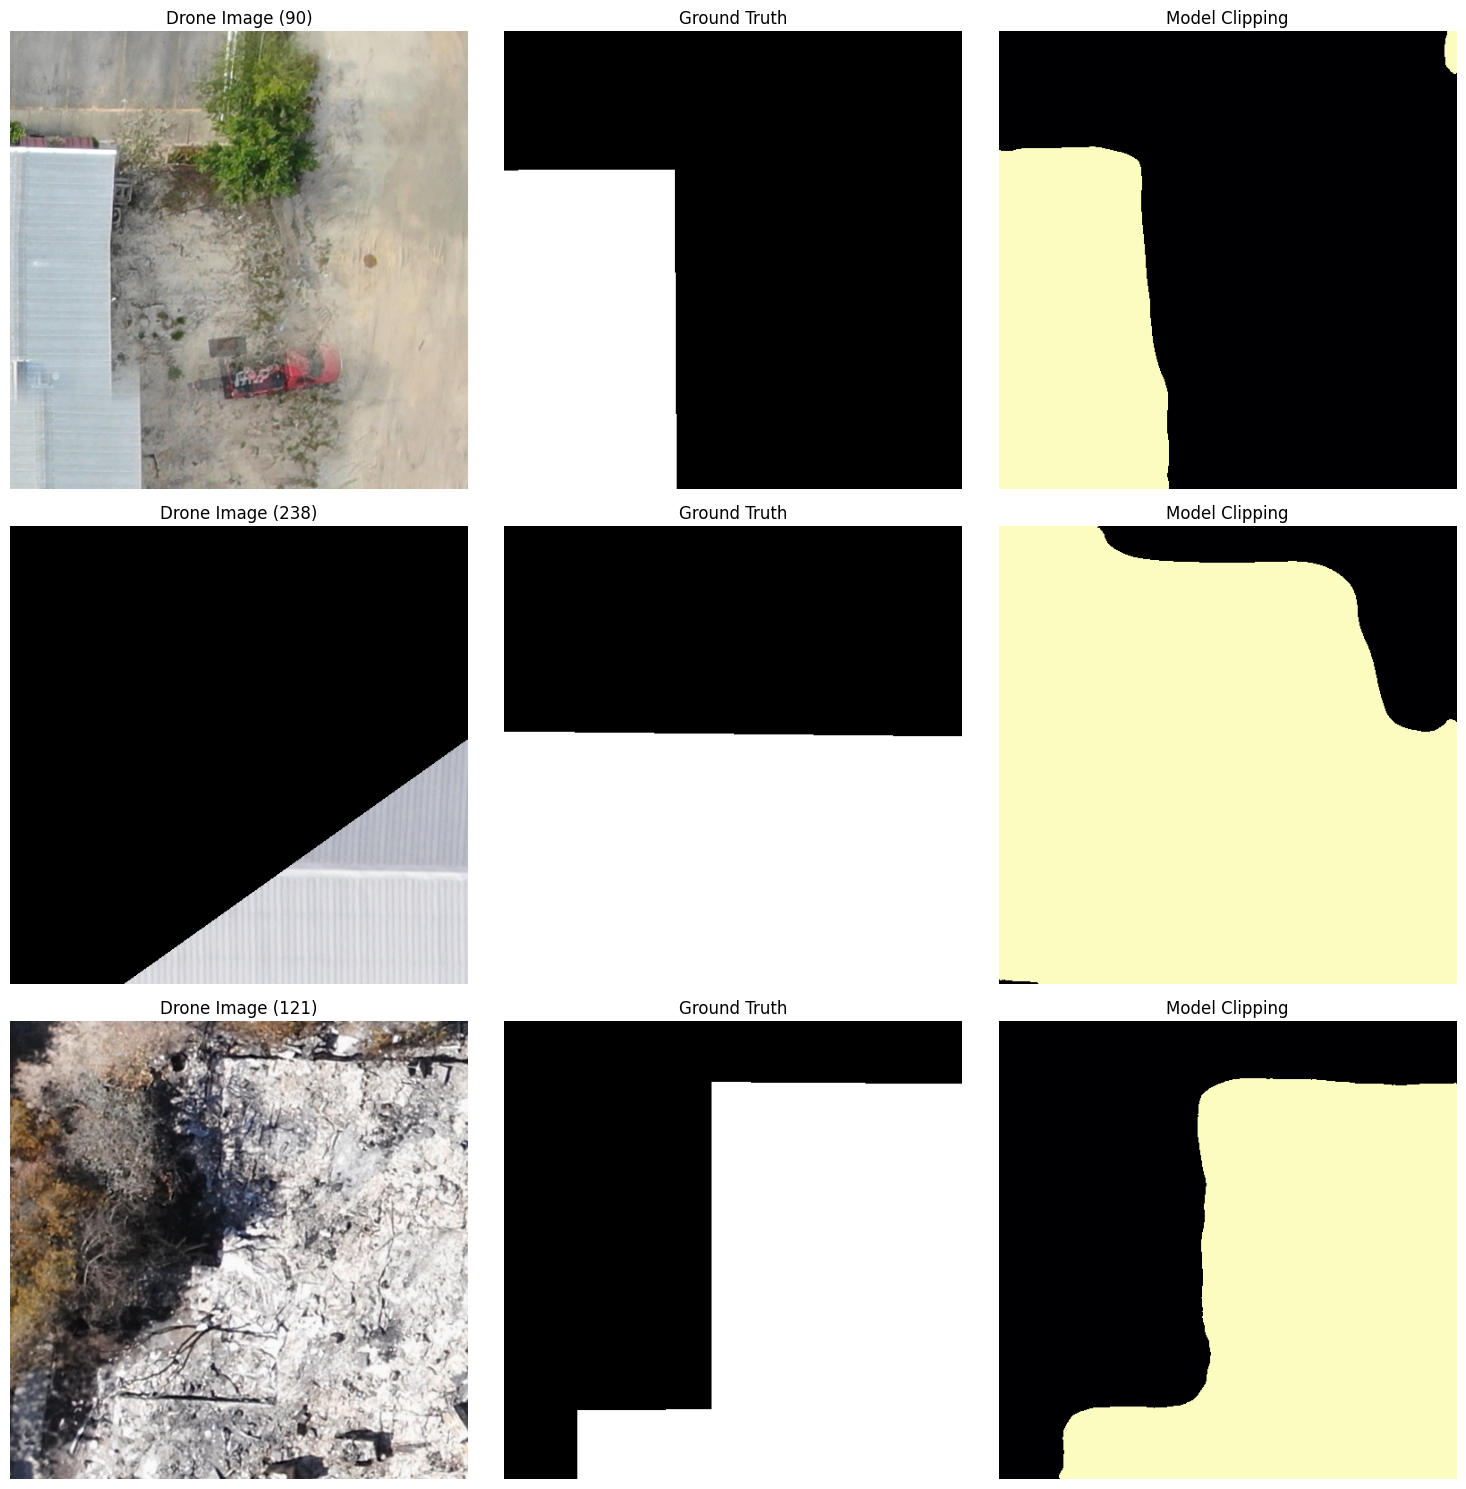

In [7]:
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, Subset
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Setup Device and Model Architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(device)

# 2. Re-create the Spatial Test Set (Images 01 & 02)
# Ensure your BuildingDataset class is defined in a cell above this!
dataset = BuildingDataset() 
test_prefixes = ['MussettBayouFire-01', 'MussettBayouFire-02']
test_indices = [i for i, f in enumerate(dataset.filenames) if any(p in f for p in test_prefixes)]
test_subset = Subset(dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

# 3. The Visualization Function
def visualize_clipping(loader, model_path, num_samples=3):
    if not os.path.exists(model_path):
        print(f"❌ Error: {model_path} not found. Check the filename!")
        return
        
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # Pick random samples from the test set
    import random
    indices = random.sample(range(len(loader.dataset)), num_samples)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for i, idx in enumerate(indices):
        image, mask = loader.dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            pred = (output.squeeze() > 0.5).cpu().numpy()
        
        img_np = image.permute(1, 2, 0).cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        
        # Plotting
        axes[i, 0].imshow(img_np); axes[i, 0].set_title(f"Drone Image ({idx})")
        axes[i, 1].imshow(mask_np, cmap='gray'); axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(pred, cmap='magma'); axes[i, 2].set_title("Model Clipping")
        for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.show()

# 4. EXECUTE
visualize_clipping(test_loader, "best_mussett_bayou_model.pth")

In [8]:
import os
import torch
import numpy as np
import random
from torch.utils.data import Subset, DataLoader

# 1. Define Geographic Split (Deterministic)
train_prefixes = ['MussettBayouFire-03', 'MussettBayouFire-04', 'MussettBayouFire-05']
test_prefixes = ['MussettBayouFire-01', 'MussettBayouFire-02']

train_building_indices = []
train_background_indices = []
test_indices = []

print("⚖️ Balancing dataset: 70% Building / 30% Background...")

for i, filename in enumerate(dataset.filenames):
    is_train = any(prefix in filename for prefix in train_prefixes)
    is_test = any(prefix in filename for prefix in test_prefixes)
    
    if is_train:
        # Load mask to check for buildings
        mask = np.load(os.path.join(dataset.mask_dir, filename))
        if np.sum(mask) > 10: # Tile has a building
            train_building_indices.append(i)
        else:
            train_background_indices.append(i)
    elif is_test:
        test_indices.append(i) # Keep 100% of test tiles for honest evaluation

# 2. Calculate 70/30 Ratio for Training
num_buildings = len(train_building_indices)
# To get 70% buildings, we need (num_buildings / 0.7) * 0.3 background tiles
num_background_needed = int((num_buildings / 0.7) * 0.3)

# Randomly pick the background tiles once (fixed seed for reproducibility)
random.seed(42)
selected_background = random.sample(train_background_indices, min(num_background_needed, len(train_background_indices)))

final_train_indices = train_building_indices + selected_background
random.shuffle(final_train_indices) # Shuffle so buildings/background are mixed

# 3. Create Subsets & Loaders
train_subset = Subset(dataset, final_train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

print(f"✅ Balanced Spatial Split Complete!")
print(f"🏠 Training: {len(train_building_indices)} Building + {len(selected_background)} Background = {len(train_subset)} Total")
print(f"🔍 Testing: {len(test_subset)} Tiles from Image 01 & 02 (Truly Unseen)")

⚖️ Balancing dataset: 70% Building / 30% Background...
✅ Balanced Spatial Split Complete!
🏠 Training: 910 Building + 0 Background = 910 Total
🔍 Testing: 257 Tiles from Image 01 & 02 (Truly Unseen)


In [10]:
import random

train_prefixes = ['MussettBayouFire-03', 'MussettBayouFire-04', 'MussettBayouFire-05']
test_prefixes = ['MussettBayouFire-01', 'MussettBayouFire-02']

train_building_indices = []
train_background_indices = []
test_indices = []

for i, filename in enumerate(dataset.filenames):
    is_train = any(prefix in filename for prefix in train_prefixes)
    is_test = any(prefix in filename for prefix in test_prefixes)
    
    if is_train:
        mask = np.load(os.path.join(dataset.mask_dir, filename))
        # Logic: If building pixels take up more than 0.2% of the tile (~500 pixels), it's a 'Building Tile'
        if np.sum(mask) > 500: 
            train_building_indices.append(i)
        else:
            # Everything else (empty tiles OR tiles with tiny sheds) counts as 'Background'
            train_background_indices.append(i)
    elif is_test:
        test_indices.append(i)

# Now, let's force the 70/30 ratio
target_bg_count = int(len(train_building_indices) * 0.3 / 0.7)
# We take as many as we can up to the target
selected_bg = random.sample(train_background_indices, min(target_bg_count, len(train_background_indices)))

final_train_indices = train_building_indices + selected_bg
random.shuffle(final_train_indices)

print(f"⚖️ New Balance: {len(train_building_indices)} Buildings / {len(selected_bg)} Backgrounds")
print(f"✅ Total Training Tiles: {len(final_train_indices)}")

⚖️ New Balance: 902 Buildings / 8 Backgrounds
✅ Total Training Tiles: 910
